<a href="https://colab.research.google.com/github/deepanshuchauhanx1/AI-Traffic-Flow-Optimizer/blob/main/notebooks/01_dataset_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/deepanshuchauhanx1/military-object-detection-ai.git

Cloning into 'military-object-detection-ai'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 31 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 11.62 KiB | 3.87 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [2]:
%cd military-object-detection-ai

/content/military-object-detection-ai


In [10]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

In [11]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.6 MB/s eta 0:00:00


In [3]:
!pip install kaggle

In [4]:
import kagglehub


dataset_path = kagglehub.dataset_download("rawsi18/military-assets-dataset-12-classes-yolo8-format")

print("Path to dataset files:", dataset_path)

100%|██████████| 3.83G/3.83G [00:32<00:00, 128MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format/versions/5


In [8]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format/versions/5"

os.listdir(dataset_path)

['military_object_dataset']

In [9]:
dataset_path = "/root/.cache/kagglehub/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format/versions/5/military_object_dataset"

os.listdir(dataset_path)

['train', 'test', 'val', 'military_dataset.yaml', 'dataset.md']

In [13]:
train_images = os.listdir(dataset_path + "/train/images")


print("Train images:", len(train_images))


Train images: 21978
Train labels: 21978


In [18]:
train_images = os.listdir(os.path.join(dataset_path, "train/images"))
val_images = os.listdir(os.path.join(dataset_path, "val/images"))
test_images = os.listdir(os.path.join(dataset_path, "test/images"))

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

Train images: 21978
Validation images: 2941
Test images: 1396


In [21]:
train_images[:10]

['020249.jpg',
 '007676.jpg',
 '014736.jpg',
 '019629.jpg',
 '015448.jpg',
 '018839.jpg',
 '007091.jpg',
 '007003.jpg',
 '020332.jpg',
 '024200.jpg']

In [23]:
with open(dataset_path + "/train/labels/015448.txt") as f:
    print(f.read())

6 0.1078125 0.6359375 0.215625 0.728125


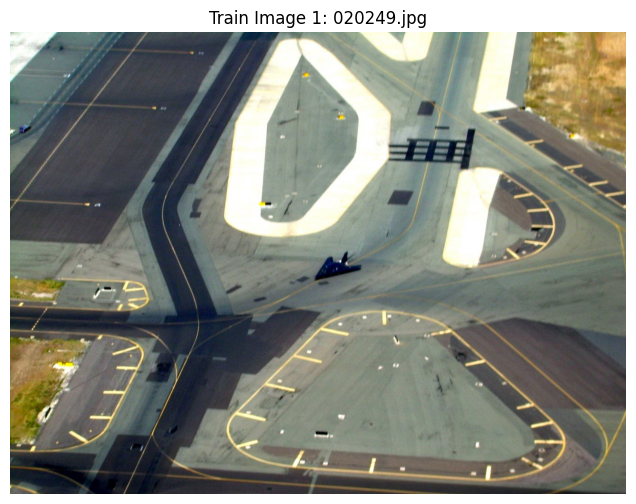

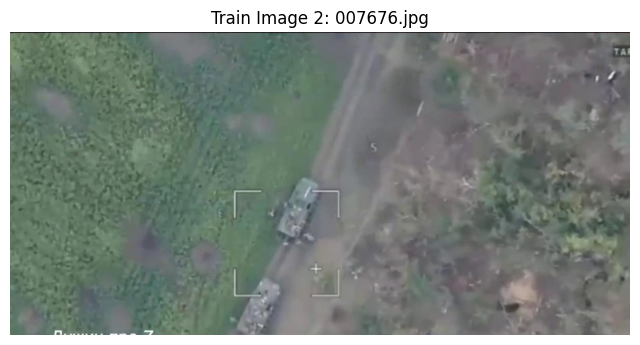

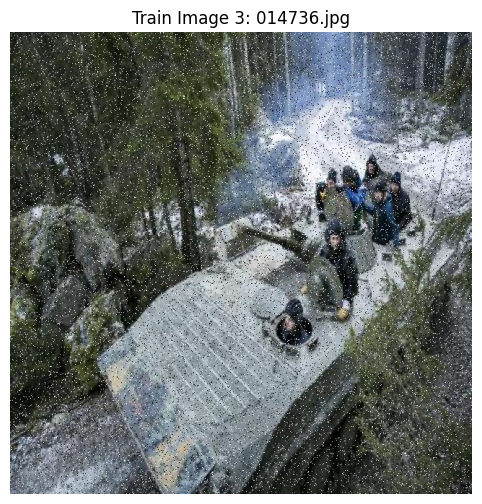

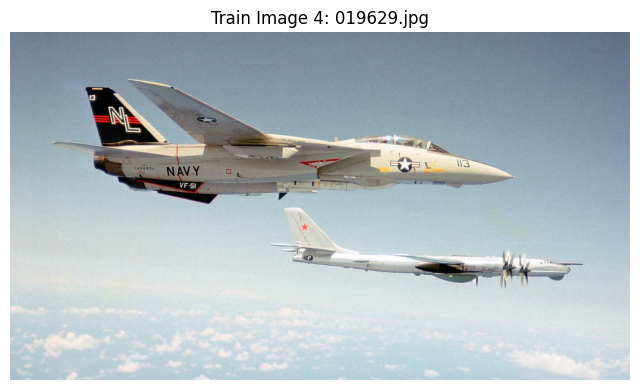

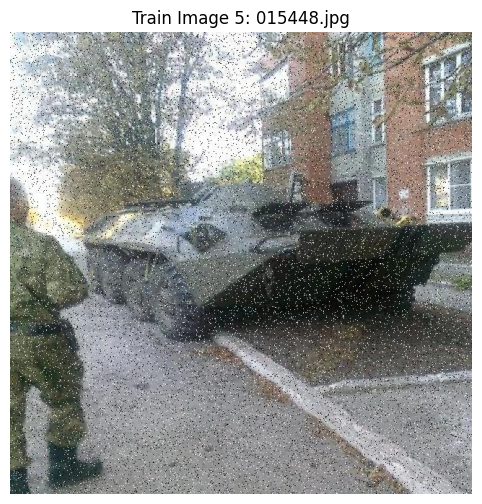

In [30]:
import cv2
import matplotlib.pyplot as plt

num_images_to_display = 5

for i in range(num_images_to_display):
    sample = train_images[i]
    img_path = os.path.join(dataset_path, "train/images", sample)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6)) # Optional: set figure size for each image
    plt.imshow(img)
    plt.title(f"Train Image {i+1}: {sample}")
    plt.axis("off")
    plt.show()

In [32]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# Paths (change if your dataset path is different)
image_dir = "train/images"
label_dir = "train/labels"

# Class names (replace with your actual classes if needed)
classes = [
    "tank","armored_vehicle","artillery","soldier",
    "military_truck","helicopter","fighter_jet",
    "warship","missile_system","radar","drone","weapon"
]

# Get random images
image_files = random.sample(os.listdir(image_dir), 6)

plt.figure(figsize=(15,10))

for i, img_file in enumerate(image_files):

    img_path = os.path.join(image_dir, img_file)
    label_path = os.path.join(label_dir, img_file.replace(".jpg",".txt"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            labels = f.readlines()

        for label in labels:
            cls, x, y, bw, bh = map(float, label.split())

            # Convert YOLO format to pixel coordinates
            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            # Draw bounding box
            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

            # Draw class label
            label_text = classes[int(cls)]
            cv2.putText(img, label_text, (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                        (255,0,0), 2)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'train/images'

In [27]:
label_path = os.path.join(dataset_path, "train/labels")

missing_labels = []

for img in train_images:
    label_file = img.replace(".jpg", ".txt")
    if not os.path.exists(os.path.join(label_path, label_file)):
        missing_labels.append(img)

print("Images without labels:", len(missing_labels))

Images without labels: 16


In [21]:
print(missing_labels[:10])

['025654.jpg', '025732.jpg', '025633.jpg', '025748.jpg', '025847.jpg', '025804.jpg', '025844.jpg', '025926.jpg', '026093.jpg', '025952.jpg']


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

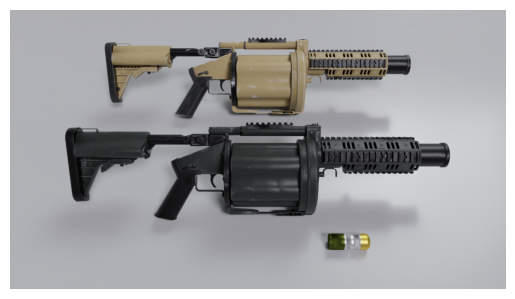

In [24]:
sample = missing_labels[1]

img_path = os.path.join(dataset_path, "train/images", sample)

import cv2
import matplotlib.pyplot as plt

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

In [ ]:
# NOTE:
# Dataset annotation mistake detected.
# 16 images contain objects but have no label files.
# These samples are removed to keep dataset annotations consistent.

In [20]:
import yaml

with open(os.path.join(dataset_path, "military_dataset.yaml")) as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

{'path': '/kaggle/input/military-assets-dataset-12-classes-yolo8-format/military_object_dataset', 'test': 'test/images', 'train': 'train/images', 'val': 'val/images', 'names': {0: 'camouflage_soldier', 1: 'weapon', 2: 'military_tank', 3: 'military_truck', 4: 'military_vehicle', 5: 'civilian', 6: 'soldier', 7: 'civilian_vehicle', 8: 'military_artillery', 9: 'trench', 10: 'military_aircraft', 11: 'military_warship'}}


In [26]:
import os

train_images_path = os.path.join(dataset_path, "train/images")

for img in missing_labels:
    img_path = os.path.join(train_images_path, img)
    if os.path.exists(img_path):
        os.remove(img_path)

In [29]:
label_path = os.path.join(dataset_path, "train/labels")

train_images = os.listdir(os.path.join(dataset_path, "train/images"))

missing_labels = []

for img in train_images:
    label_file = img.replace(".jpg", ".txt")
    if not os.path.exists(os.path.join(label_path, label_file)):
        missing_labels.append(img)

print("Images without labels:", len(missing_labels))

Images without labels: 0


In [30]:
train_images = os.listdir(os.path.join(dataset_path, "train/images"))
print("Total train images:", len(train_images))

Total train images: 181
